# **GEREKLİ IMPORTLAR**
Bu bölümde gerekli kütüphane ve modüllerin içeri aktarımı yapıldı.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.metrics import accuracy_score
from scipy.sparse import issparse
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import seaborn as sns 
import matplotlib.pyplot as plt
 
from models import PegasosSVM, MLP
from data_handler import prepare_higgs_subset, prepare_rcv1_subset

print("Yüklenen Modüller: models.py, data_handler.py")

## **PEGASOS SVM'NİN HIGGS VERİ SETİ İLE EĞİTİLMESİ VE SONUÇLARIN GÖRSELLEŞTİRİLMESİ**
Bu bölümde yazılan Pegasos SVM modeli HIGGS veri seti ile eğitildi, Loss ve Confusion Matrix ile modelin bu veri seti üzerindeki performansı görselleştirildi.  

Kayıtlı veri yok. İndiriliyor.
Dosya bulundu diskten okunuyor
[DATA_HANDLER] HIGGS hazırlığı tamamlandı.
Eğitim Başlatılıyor
-----------------
Accuracy: %64.38
F1-Score: 0.7062
-----------------
Sınıflandırma Raporu:
               precision    recall  f1-score   support

          -1       0.69      0.45      0.55      1896
           1       0.62      0.81      0.71      2104

    accuracy                           0.64      4000
   macro avg       0.66      0.63      0.63      4000
weighted avg       0.65      0.64      0.63      4000



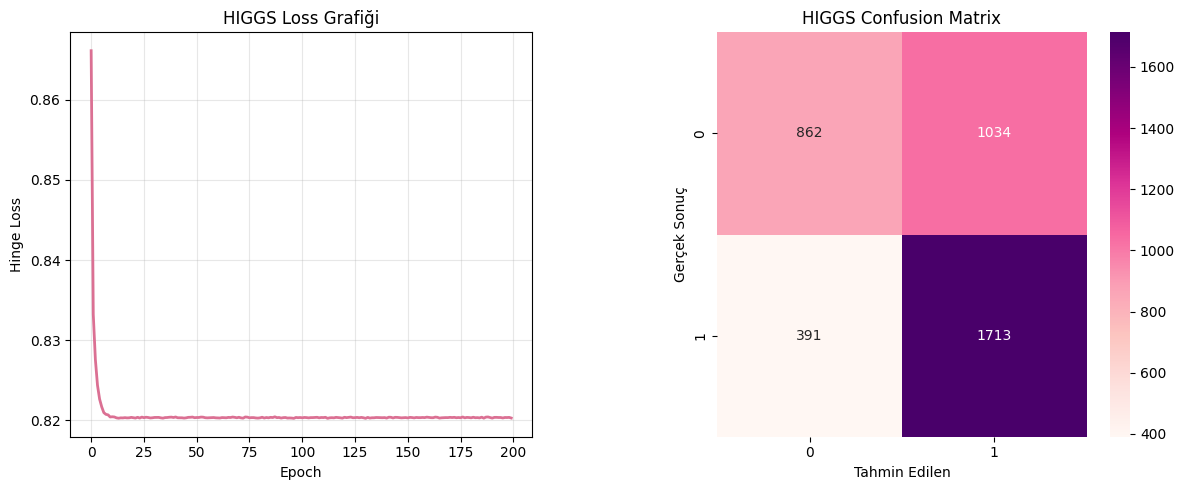

In [2]:
CACHE_HIGGS = "higgs_data_cache.npz"

""" 
    HIGGS veri setinin büyüklüğü kaynaklı her kodu çalıştırmada yaşanan uzun beklemeleri önlemek için önbellekleme işlemi yapıldı.
    Bu sayede veri bir kere indirildikten sonra diğer çalıştırmalarda kodun hızlı bir şekilde çalışması sağlandı. 
"""

if os.path.exists(CACHE_HIGGS):
    # Veri kayıtlıysa diskten okunup çalıştırıldı.
    print(f"Kayıtlı veri bulundu: '{CACHE_HIGGS}'")
    with np.load(CACHE_HIGGS) as data:
        X_train_h = data['X_train']
        X_test_h = data['X_test']
        y_train_h = data['y_train']
        y_test_h = data['y_test']
else:
    # Veri kayıtlı değilse sonraki çalıştırmalar için sıkıştırılmış bir şekilde kaydedildi.
    print("Kayıtlı veri yok. İndiriliyor.")
    X_train_h, X_test_h, y_train_h, y_test_h = prepare_higgs_subset(total_samples=20000)   
    np.savez(CACHE_HIGGS, X_train=X_train_h, X_test=X_test_h, y_train=y_train_h, y_test=y_test_h) 

"""
    SVM'nin matematiksel formülü (Hinge Loss) etiketlerin -1 ve 1 olmasını gerektirdiğinden etiket dönüşümü yapıldı.
    Ayrıca boyut hatasını önleme amacıyla .ravel() kullanılarak etiket dizisi vektör haline getirildi.
"""

y_train_h_svm = np.where(y_train_h.ravel() == 0, -1, 1)
y_test_h_svm = np.where(y_test_h.ravel() == 0, -1, 1)

""" 
    Pegasos SVM modelinin hiperparametreleri belirlenerek model eğitimi başlatıldı.

    Learning Rate: Veri gürültülü olduğundan düşük bir öğrenme hızı seçildi.
    L2 Regülarizasyon Katsayısı (Lambda): Aşırı öğrenmeyi engelleme amacıyla kullanıldı.
    Epoch Number: Loss grafiği için veri setinin üzerinden 200 kez geçilmesi uygun görüldü.
"""
print("Eğitim Başlatılıyor")
model_higgs = PegasosSVM(learning_rate=0.001, lambda_param=0.0001, epoch_number=200) # Parametreler belirlendi.
model_higgs.fit(X_train_h, y_train_h_svm) # Model eğitim verisiyle beslenip ağırlıkların güncellenmesi sağlandı.
y_pred_h = model_higgs.predict(X_test_h) # Test verisi üzerinden tahmin yapıldı.

"""
    Sonuçlar Görselleştirildi.
    Kullanılan performans metrikleri: accuracy (genel doğruluk oranı), f1-score (Presicion ve Recall'un harmonik ortalaması)    
"""
acc = accuracy_score(y_test_h_svm, y_pred_h)
f1 = f1_score(y_test_h_svm, y_pred_h)
cm = confusion_matrix(y_test_h_svm, y_pred_h) 

# Accuracy (yüzdelik olarak) ve f1-score yazdırıldı.
print("-" * 17)
print(f"Accuracy: %{acc * 100:.2f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 17)

# Presicion, Recall, f1-score ve Support değerlerini detaylı gösteren rapor yazdırıldı.
print("Sınıflandırma Raporu:\n", classification_report(y_test_h_svm, y_pred_h))

"""
    Loss Matrix ve Confusion Matrix görselleştirildi.  

    Loss Matrix ile modelin her epoch ile hatasının nasıl azaldığı gösterildi.
    Confusion Matrix ile modelin hata yapma miktarı gösterildi.
"""

# Yan yana iki grafik oluşturuldu.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss Matrix Görselleştirildi.
ax[0].plot(model_higgs.loss_history, linewidth = 2, color = 'palevioletred')
ax[0].set_title("HIGGS Loss Grafiği")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Hinge Loss")
ax[0].grid(True, alpha = 0.3)

# Confusion Matrix Görselleştirildi.
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax[1])
ax[1].set_title("HIGGS Confusion Matrix")
ax[1].set_ylabel("Gerçek Sonuç")
ax[1].set_xlabel("Tahmin Edilen")

# Grafiklerin düzgün gösterilmesi için gerekli ayarlar yapıldı.
plt.tight_layout()
plt.subplots_adjust(wspace = 0.4) # Grafiklerin çok yakın durmaması ve okunaklı olması amacıyla boşluk eklendi.
plt.show()

## **PEGASOS SVM'NİN RCV1 / REUTERS VERİ SETİ İLE EĞİTİLMESİ VE SONUÇLARIN GÖRSELLEŞTİRİLMESİ**
Bu bölümde yazılan Pegasos SVM modeli RCV1/Reuters veri seti ile eğitildi, Loss ve Confusion Matrix ile modelin bu veri seti üzerindeki performansı görselleştirildi.  


[DATA_HANDLER] Reuters verisi hazırlanıyor.
Metinler decode ediliyor.
TF-IDF dönüşümü yapılıyor.
[DATA_HANDLER] Reuters hazırlığı tamamlandı.
Veri yapısı seyrek mi?: True
Train Boyutu: (8982, 10000), Test Boyutu: (2246, 10000)
Eğitim Başlatıldı.
-----------------
Accuracy: %94.03
F1-Score: 0.9189
-----------------
Sınıflandırma Raporu:
               precision    recall  f1-score   support

          -1       0.94      0.97      0.95      1401
           1       0.94      0.90      0.92       845

    accuracy                           0.94      2246
   macro avg       0.94      0.93      0.94      2246
weighted avg       0.94      0.94      0.94      2246



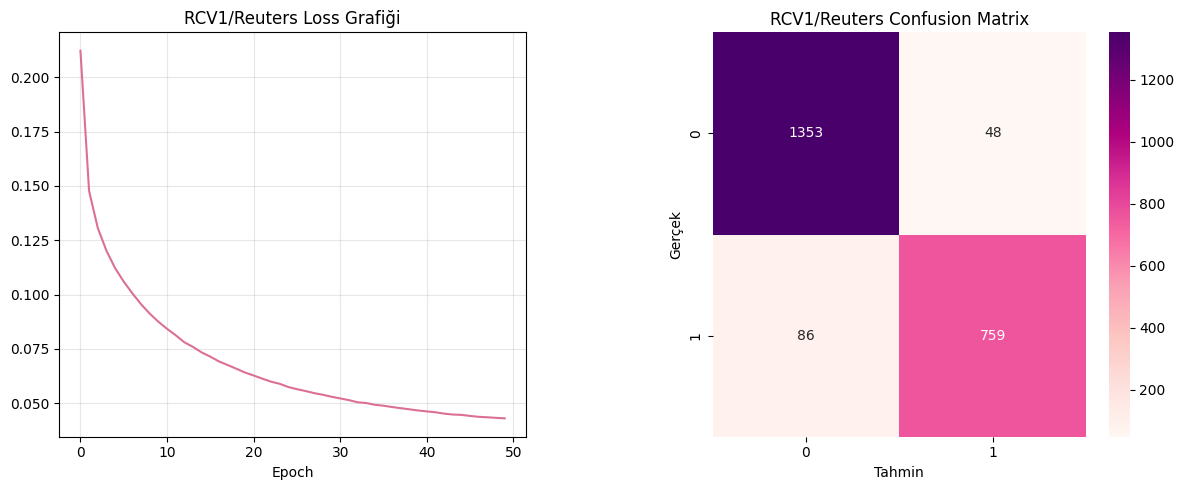

In [3]:
"""
    Veri yükleme yapıldı. Bu veri seti üzerinde daha hızlı çalışıldığından önbelleklemeye ihtiyaç duyulmadı.    
"""

# data_handler içinde tanımlı olan alt küme çağırıldı.
X_train_r, X_test_r, y_train_r, y_test_r = prepare_rcv1_subset(n_samples=None)

"""
    SVM'nin matematiksel formülü (Hinge Loss) etiketlerin -1 ve 1 olmasını gerektirdiğinden etiket dönüşümü yapıldı.
"""

y_train_r_svm = np.where(y_train_r == 0, -1, 1)
y_test_r_svm = np.where(y_test_r == 0, -1, 1)

# Veri yapısı kontrol edildi.
print(f"Veri yapısı seyrek mi?: {issparse(X_train_r)}")
print(f"Train Boyutu: {X_train_r.shape}, Test Boyutu: {X_test_r.shape}")

""" 
    Pegasos SVM modelinin hiperparametreleri belirlenerek model eğitimi başlatıldı.

    Learning Rate: Seyrek metin verilerinde modelin daha hızlı öğrenmesi gerektiği tespit edildi. Bu sebeple daha yüksek bir öğrenme hızı seçildi.
    L2 Regülarizasyon Katsayısı (Lambda): Metin verisi genelde lineer ayrılabilir olduğundan daha düşük bir lambda katsayısı yeterli bulundu.
    Epoch Number: Loss grafiği için veri setinin üzerinden 50 kez geçilmesi uygun görüldü.
"""

print("Eğitim Başlatıldı.")
model_rcv = PegasosSVM(learning_rate=0.1, lambda_param=0.00001, epoch_number=50)
model_rcv.fit(X_train_r, y_train_r_svm) # Model eğitim verisiyle beslenip ağırlıkların güncellenmesi sağlandı.
y_pred_r = model_rcv.predict(X_test_r) # Test verisi üzerinden tahmin yapıldı.

"""
    Sonuçlar Görselleştirildi.
    Kullanılan performans metrikleri: accuracy (genel doğruluk oranı), f1-score (Presicion ve Recall'un harmonik ortalaması)    
"""
acc = accuracy_score(y_test_r_svm, y_pred_r)
f1 = f1_score(y_test_r_svm, y_pred_r)
cm = confusion_matrix(y_test_r_svm, y_pred_r)

# Accuracy (yüzdelik olarak) ve f1-score yazdırıldı.
print("-" * 17)
print(f"Accuracy: %{acc * 100:.2f}")
print(f"F1-Score: {f1:.4f}")
print("-" * 17)

# Presicion, Recall, f1-score ve Support değerlerini detaylı gösteren rapor yazdırıldı.
print("Sınıflandırma Raporu:\n", classification_report(y_test_r_svm, y_pred_r))

"""
    Loss Matrix ve Confusion Matrix görselleştirildi.  

    Loss Matrix ile modelin her epoch ile hatasının nasıl azaldığı gösterildi.
    Confusion Matrix ile modelin hata yapma miktarı gösterildi.
"""
# Yan yana iki grafik oluşturuldu.
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Loss Matrix Görselleştirildi.
ax[0].plot(model_rcv.loss_history, color='palevioletred')
ax[0].set_title("RCV1/Reuters Loss Grafiği")
ax[0].set_xlabel("Epoch")
ax[0].grid(True, alpha = 0.3)

# Confusion Matrix Görselleştirildi.
sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu', ax=ax[1])
ax[1].set_title("RCV1/Reuters Confusion Matrix")
ax[1].set_ylabel("Gerçek")
ax[1].set_xlabel("Tahmin")

# Grafiklerin düzgün gösterilmesi için gerekli ayarlar yapıldı.
plt.tight_layout()
plt.subplots_adjust(wspace = 0.4) # Grafiklerin çok yakın durmaması ve okunaklı olması amacıyla boşluk eklendi.
plt.show()

## **FARKLI LEARNING RATE DEĞERLERİNİN KARŞILAŞTIRILMASI**
Bu bölümde Pegasos SVM modelinin öğrenme hızının HIGGS ve RCV1/Reuters verileri üzerindeki etkileri incelendi ve görselleştirildi. Farklı veri setleri için de kullanılabilecek esnek bir yapı olarak tasarlandı.

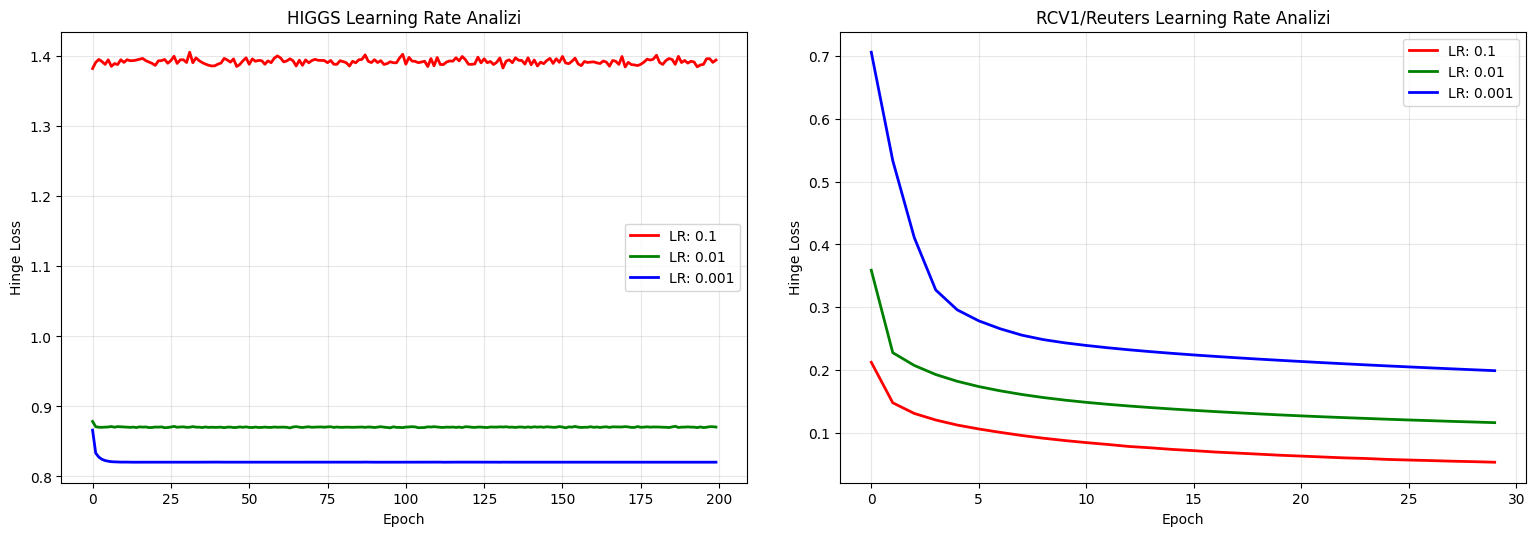

In [4]:
"""
    Bu fonksiyon, Pegasos SVM modelinin öğrenme hızını analiz edip görselleştirir.
    Fonksiyon her öğrenme hızı için geçici bir SVM modeli oluşturur ve eğitim boyunca kaydedilen hata geçmişini grafiğer döker.
"""
def analyze_learning_rate(ax, X_train, y_train, dataset_name, lambda_value, epochs):
   
    learning_rates = [0.1, 0.01, 0.001] # Karşılaştırılacak Learning Rate değerleri tanımlandı.
    colors = ['red', 'green', 'blue'] # Renk ayarları yapıldı.
    
    for lr, col in zip(learning_rates, colors): # zip() kullanılarak renk ve öğrenme hızı listeleri döngü boyunca eşleştirilir    
        temp_model = PegasosSVM(learning_rate=lr, lambda_param=lambda_value, epoch_number=epochs)
        temp_model.fit(X_train, y_train)   
        ax.plot(temp_model.loss_history, label=f'LR: {lr}', color=col, linewidth=2)

    # Grafik ayarları yapıldı.
    ax.set_title(f"{dataset_name} Learning Rate Analizi") 
    ax.set_xlabel("Epoch") # 
    ax.set_ylabel("Hinge Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig, ax = plt.subplots(1, 2, figsize=(16, 6)) # Yan yana iki grafik oluşturuldu.

"""
    Oluşturulan analyze_learning_rate() fonksiyonu her iki veri seti için de çağırıldı.
"""
# HIGGS için learning rate analizi yapıldı.
analyze_learning_rate(ax=ax[0], X_train=X_train_h, y_train=y_train_h_svm, dataset_name="HIGGS", lambda_value=0.0001, epochs=200)

# RCV1/REUTERS learning rate analizi yapıldı.
analyze_learning_rate(ax=ax[1], X_train=X_train_r, y_train=y_train_r_svm, dataset_name="RCV1/Reuters", lambda_value=0.00001, epochs=30)

# Grafiklerin düzgün gösterilmesi için gerekli ayarlar yapıldı.
plt.tight_layout(pad=3.0)
plt.show()

## **OPTIMIZER ANALİZLERİ VE AKTİVASYON KARŞILAŞTIRMASI**
Bu bölümde farklı optimizasyon algoritmalarının MLP modeli üzerindeki etkileri karşılaştırıldı.


Optimizer: SGD
Epoch 10/50 - Loss: 0.6868
Epoch 20/50 - Loss: 0.6817
Epoch 30/50 - Loss: 0.6771
Epoch 40/50 - Loss: 0.6728
Epoch 50/50 - Loss: 0.6686

Optimizer: MOMENTUM
Epoch 10/50 - Loss: 0.6500
Epoch 20/50 - Loss: 0.6280
Epoch 30/50 - Loss: 0.6139
Epoch 40/50 - Loss: 0.6019
Epoch 50/50 - Loss: 0.5913

Optimizer: RMSPROP
Epoch 10/50 - Loss: 0.5581
Epoch 20/50 - Loss: 0.5230
Epoch 30/50 - Loss: 0.5030
Epoch 40/50 - Loss: 0.4777
Epoch 50/50 - Loss: 0.4583

Optimizer: ADAM
Epoch 10/50 - Loss: 0.5476
Epoch 20/50 - Loss: 0.5098
Epoch 30/50 - Loss: 0.4871
Epoch 40/50 - Loss: 0.4666
Epoch 50/50 - Loss: 0.4445


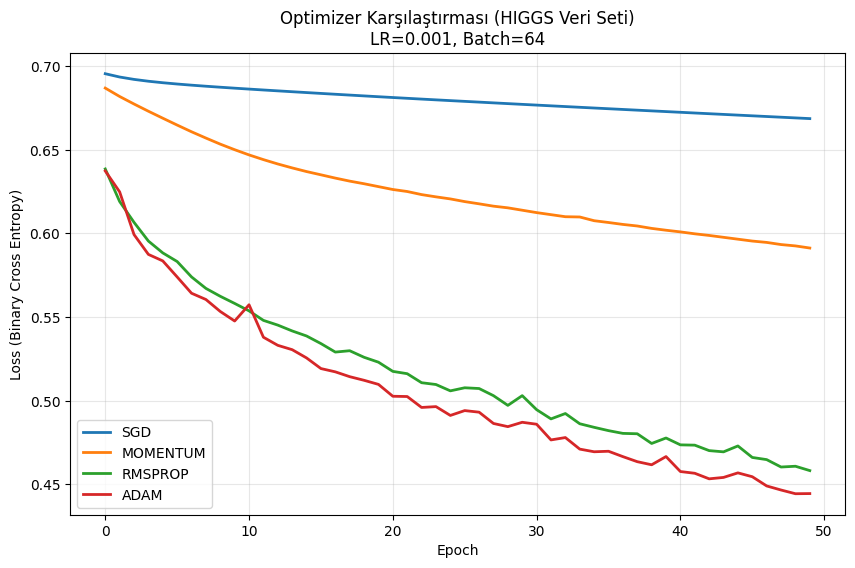


Aktivasyon Fonksiyonları Karşılaştırılıyor
Activation: SIGMOID
Epoch 10/50 - Loss: 0.6281
Epoch 20/50 - Loss: 0.6017
Epoch 30/50 - Loss: 0.5802
Epoch 40/50 - Loss: 0.5657
Epoch 50/50 - Loss: 0.5512
Activation: TANH
Epoch 10/50 - Loss: 0.5819
Epoch 20/50 - Loss: 0.5227
Epoch 30/50 - Loss: 0.4883
Epoch 40/50 - Loss: 0.4630
Epoch 50/50 - Loss: 0.4364
Activation: RELU
Epoch 10/50 - Loss: 0.5476
Epoch 20/50 - Loss: 0.5098
Epoch 30/50 - Loss: 0.4871
Epoch 40/50 - Loss: 0.4666
Epoch 50/50 - Loss: 0.4445


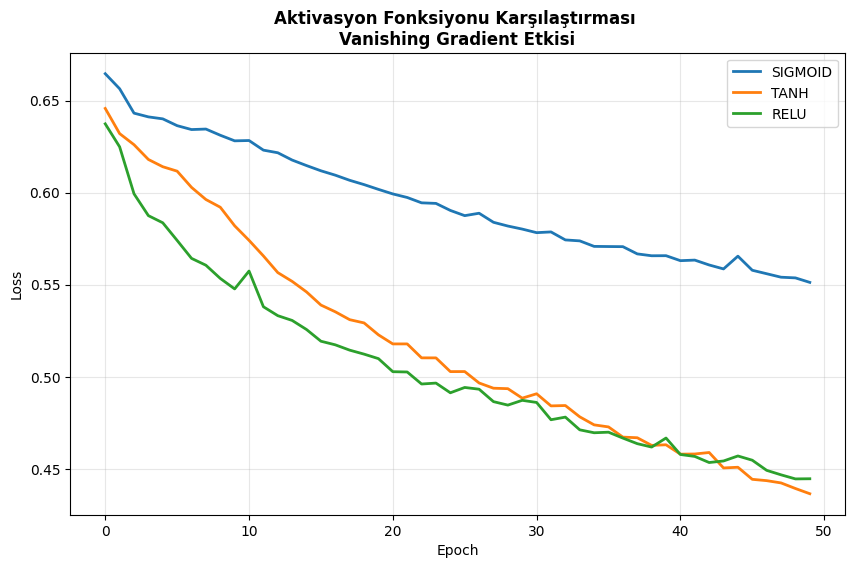

In [5]:
from models import MLP
import matplotlib.pyplot as plt

# MLP giriş katmanının boyutu belirlendi.
input_dim = X_train_h.shape[1]

# Karşılaştırılacak optimizasyon algoritmalarının listesi hazırlandı.
optimizers = ['sgd', 'momentum', 'rmsprop', 'adam']

# Her optimizasyon algoritmasının eğitim sırasındaki hata geçmişini saklamak için sözlük oluşturuldu.
loss_histories = {}

epochs = 50 # Eğitim döngü sayısı belirlendi.
batch_size = 64 # Her adımda işlenen veri sayısı belirlendi.
learning_rate = 0.001 # Öğrenme hızı belirlendi
layer_structure = [input_dim, 64, 32, 1] # Model mimarisi tanımlandı. 2 Gizli Katmanlı Mimari oluşturuldu.

for opt in optimizers:
    print(f"\nOptimizer: {opt.upper()}")
    
    # Belirtilen optimizer türüne göre yeni bir MLP nesnesi oluşturuldu.
    mlp = MLP(layer_sizes=layer_structure, activation='relu', optimizer=opt, learning_rate=learning_rate, epochs=epochs, batch_size=batch_size)
    
    # HIGGS eğitim verisi ile ağırlıklar güncellendi.
    mlp.fit(X_train_h, y_train_h) 
    
    # Hata geçmişi sözlüğe eklendi.
    loss_histories[opt] = mlp.loss_history

# Kaydedilen her bir optimizasyon algoritmasının loss eğrisini çizdirildi.
plt.figure(figsize=(10, 6))
for opt, losses in loss_histories.items():
    plt.plot(losses, label=opt.upper(), linewidth=2)

# Grafiklerin düzgün gösterilmesi için gerekli ayarlar yapıldı.
plt.title(f"Optimizer Karşılaştırması (HIGGS Veri Seti)\nLR={learning_rate}, Batch={batch_size}")
plt.xlabel("Epoch")
plt.ylabel("Loss (Binary Cross Entropy)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# AKTİVASYON KARŞILAŞTIRMASI 

activations = ['sigmoid', 'tanh', 'relu']
loss_histories_act = {}

print("\nAktivasyon Fonksiyonları Karşılaştırılıyor")

for act in activations:
    print(f"Activation: {act.upper()}")
    
    # Optimizer 'adam' olarak seçildi.
    mlp = MLP(layer_sizes=layer_structure, activation=act, optimizer='adam', learning_rate=0.001, epochs=epochs, batch_size=batch_size)
    
    mlp.fit(X_train_h, y_train_h)
    loss_histories_act[act] = mlp.loss_history

# Grafik Çizimi
plt.figure(figsize=(10, 6))
for act, losses in loss_histories_act.items():
    plt.plot(losses, label=act.upper(), linewidth=2)

# Grafiklerin düzgün gösterilmesi için gerekli ayarlar yapıldı.
plt.title(f"Aktivasyon Fonksiyonu Karşılaştırması \nVanishing Gradient Etkisi", fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **AKTİVASYON FONKSİYONLARININ ANALİZİ**
Bu bölümde farklı aktivasyon fonksiyonlarının etkileri incelenip görselleştirildi.

Aktivasyon Fonksiyonu: RELU
Epoch 10/50 - Loss: 0.5421
Epoch 20/50 - Loss: 0.4965
Epoch 30/50 - Loss: 0.4546
Epoch 40/50 - Loss: 0.4265
Epoch 50/50 - Loss: 0.4056
Aktivasyon Fonksiyonu: SIGMOID
Epoch 10/50 - Loss: 0.6284
Epoch 20/50 - Loss: 0.6038
Epoch 30/50 - Loss: 0.5785
Epoch 40/50 - Loss: 0.5627
Epoch 50/50 - Loss: 0.5499


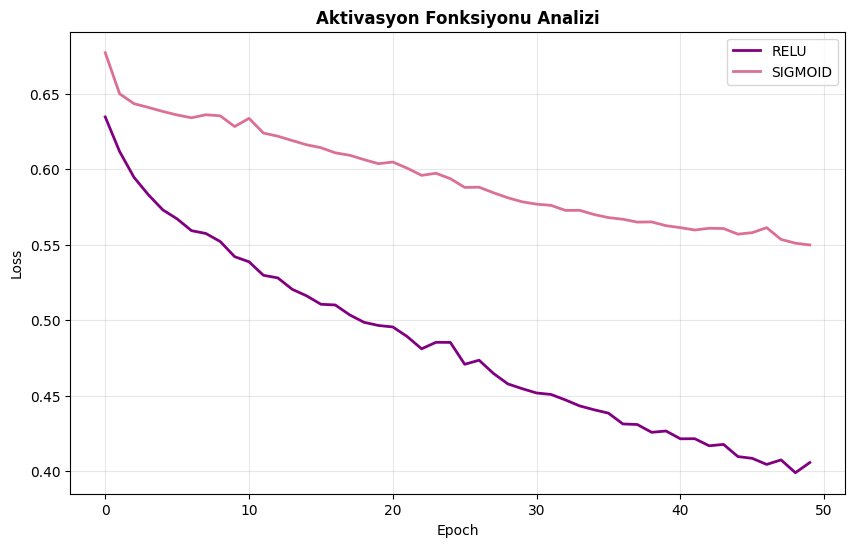

In [6]:
# Vanishing Gradient etkisini gözlemleyebilmek için derin bir ağ oluşturuldu.
structure = [X_train_h.shape[1], 64, 32, 16, 1] # 3 Gizli Katman kullanıldı.

activations = ['relu', 'sigmoid'] # Karşılaştırılacak fonksiyonların listesi.
colors = ['purple', 'palevioletred'] # Kullanılacak renklerin listesi.

plt.figure(figsize=(10, 6))

for act, col in zip(activations, colors):
    print(f"Aktivasyon Fonksiyonu: {act.upper()}")
    
    # Aktivasyon fonksiyonu hariç tüm parametreler sabit tutuldu.
    temp_mlp = MLP(layer_sizes=structure, activation=act, optimizer='adam', learning_rate=0.001, epochs=50, batch_size=64)   
    temp_mlp.fit(X_train_h, y_train_h)
    # Modelin loss geçmişi grafiğe döküldü.
    plt.plot(temp_mlp.loss_history, label=f'{act.upper()}', color=col, linewidth=2)

# Grafik ayarları yapıldı.
plt.title("Aktivasyon Fonksiyonu Analizi", fontsize=12, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## **MLP'NİN HIGGS VE RCV1/REUTERS İÇİN LOSS GRAFİĞİ VE CONFUSION MATRİSİ**
Bu bölümde MLP'nin HIGGS ve RCV1/Reuters için başarı metrikleri hesaplandı. Ayrıca loss grafiği ve confusion matrisi de görselleştirildi.


HIGGS MLP Eğitimi (Adam + ReLU)
Epoch 10/50 - Loss: 0.5476
Epoch 20/50 - Loss: 0.5098
Epoch 30/50 - Loss: 0.4871
Epoch 40/50 - Loss: 0.4666
Epoch 50/50 - Loss: 0.4445
Accuracy: %67.47
F1-Score: 0.6835

RCV1 MLP Eğitimi
Epoch 10/30 - Loss: 0.0356
Epoch 20/30 - Loss: 0.0274
Epoch 30/30 - Loss: 0.0278
Accuracy: %93.50
F1-Score: 0.9138


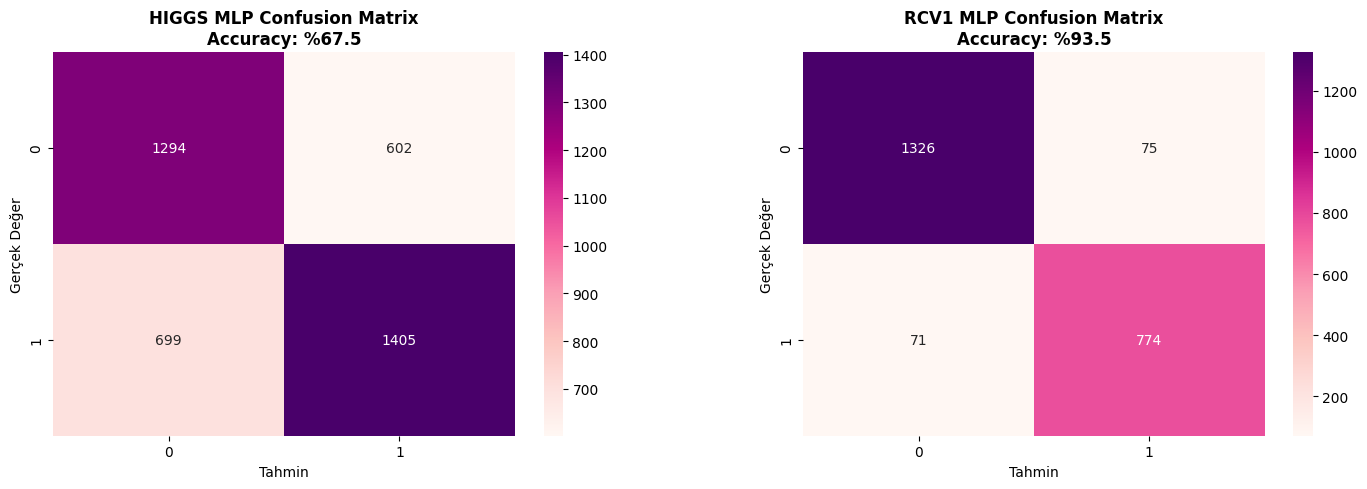

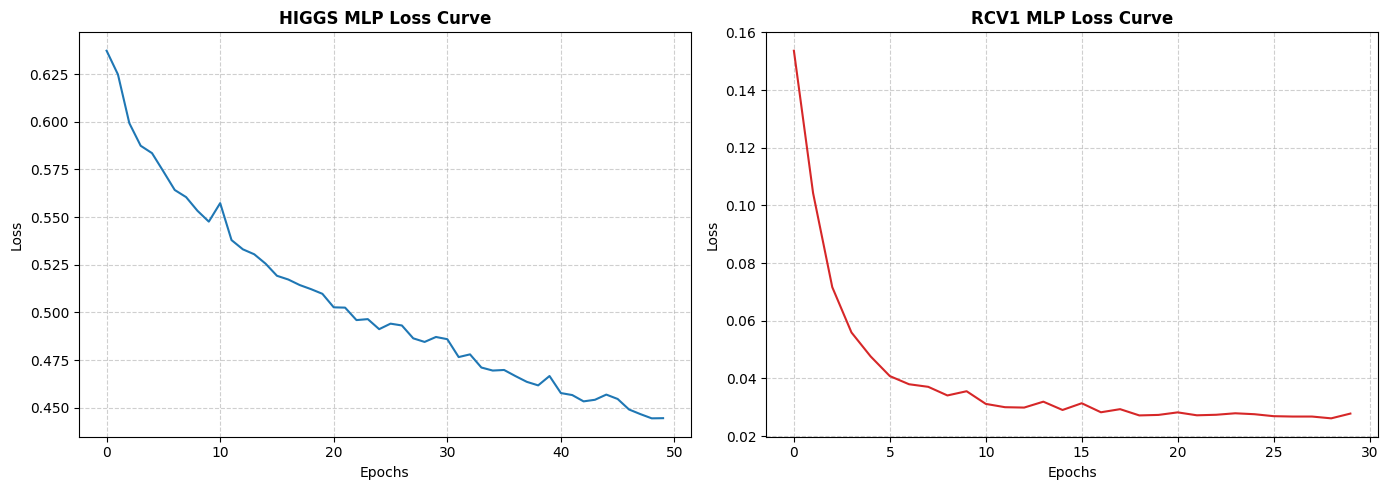

In [7]:
print("\nHIGGS MLP Eğitimi (Adam + ReLU)")

# HIGGS için 2 gizli katman yeterli bulunmuştur.
best_mlp_h = MLP(layer_sizes=[X_train_h.shape[1], 64, 32, 1], activation='relu', optimizer='adam', learning_rate=0.001, epochs=50, batch_size=64)
best_mlp_h.fit(X_train_h, y_train_h)
y_pred_h_mlp = best_mlp_h.predict(X_test_h)

# Metrikler
acc_h = accuracy_score(y_test_h, y_pred_h_mlp)
f1_h = f1_score(y_test_h, y_pred_h_mlp)
print(f"Accuracy: %{acc_h * 100:.2f}")
print(f"F1-Score: {f1_h:.4f}")

# Kernel sıfırlanmasına karşı önlem alındı.
if 'X_train_r' not in locals():
    X_train_r, X_test_r, y_train_r, y_test_r = prepare_rcv1_subset(n_samples=None)

print("\nRCV1 MLP Eğitimi")
# RCV1 için giriş boyutu çok büyük olduğu için ilk katman geniş tutuldu.
best_mlp_r = MLP(layer_sizes=[X_train_r.shape[1], 128, 64, 1], activation='relu', optimizer='adam', learning_rate=0.001, epochs=30, batch_size=128)  
best_mlp_r.fit(X_train_r, y_train_r)
y_pred_r_mlp = best_mlp_r.predict(X_test_r)

# Gerekli metrikler belirlendi.
acc_r = accuracy_score(y_test_r, y_pred_r_mlp)
f1_r = f1_score(y_test_r, y_pred_r_mlp)
print(f"Accuracy: %{acc_r * 100:.2f}")
print(f"F1-Score: {f1_r:.4f}")

# CONFUSION MATRİSLERİ

# HIGGS İçin Confusion Matrix hazırlandı.
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cm_h = confusion_matrix(y_test_h, y_pred_h_mlp)
sns.heatmap(cm_h, annot=True, fmt='d', cmap='RdPu', ax=ax[0])
ax[0].set_title(f"HIGGS MLP Confusion Matrix\nAccuracy: %{acc_h*100:.1f}", fontweight='bold')
ax[0].set_ylabel("Gerçek Değer")
ax[0].set_xlabel("Tahmin")

# RCV1 İçin Confusion Matrix hazırlandı.
cm_r = confusion_matrix(y_test_r, y_pred_r_mlp)
sns.heatmap(cm_r, annot=True, fmt='d', cmap='RdPu', ax=ax[1])
ax[1].set_title(f"RCV1 MLP Confusion Matrix\nAccuracy: %{acc_r*100:.1f}", fontweight='bold')
ax[1].set_ylabel("Gerçek Değer")
ax[1].set_xlabel("Tahmin")

plt.tight_layout()
plt.subplots_adjust(wspace = 0.3) # Grafiklerin çok yakın durmaması ve okunaklı olması amacıyla boşluk eklendi.
plt.show()

# LOSS GRAFİKLERİ 

fig_loss, ax_loss = plt.subplots(1, 2, figsize=(14, 5))

# HIGGS İçin Loss grafiği hazırlandı.
ax_loss[0].plot(best_mlp_h.loss_history, label='Training Loss', color='tab:blue')
ax_loss[0].set_title("HIGGS MLP Loss Curve", fontweight='bold')
ax_loss[0].set_xlabel("Epochs")
ax_loss[0].set_ylabel("Loss")
ax_loss[0].grid(True, linestyle='--', alpha=0.6)

# RCV1 İçin Loss grafiği hazırlandı.
ax_loss[1].plot(best_mlp_r.loss_history, label='Training Loss', color='tab:red')
ax_loss[1].set_title("RCV1 MLP Loss Curve", fontweight='bold')
ax_loss[1].set_xlabel("Epochs")
ax_loss[1].set_ylabel("Loss")
ax_loss[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## **ENSEMBLE YAPISI**
bu bölümde iki modeli birleştiren hibrit bir model oluşturuldu ve karşılaştırılması yapıldı.

In [8]:
# Modeller hafızada yoksa, en iyi parametrelerle tekrar oluşturduk.

if 'best_higgs' not in locals():
    print("HIGGS SVM eğitiliyor")
    best_higgs = PegasosSVM(learning_rate=0.001, lambda_param=0.0001, epoch_number=100)
    best_higgs.fit(X_train_h, y_train_h_svm)

if 'best_mlp_h' not in locals():
    print("HIGGS MLP eğitiliyor")
    best_mlp_h = MLP(layer_sizes=[X_train_h.shape[1], 64, 32, 1], activation='relu', optimizer='adam', learning_rate=0.001, epochs=50, batch_size=64)
    best_mlp_h.fit(X_train_h, y_train_h) # y_train_h kullanıyoruz (0/1)

if 'best_rcv' not in locals():
    print("RCV1 SVM eğitiliyor")
    best_rcv = PegasosSVM(learning_rate=0.1, lambda_param=0.00001, epoch_number=50)
    best_rcv.fit(X_train_r, y_train_r_svm)

# RCV1 MLP (Adam + ReLU)
if 'best_mlp_r' not in locals():
    print("RCV1 MLP eğitiliyor...")
    # Eğer veri seti yoksa yükle.
    if 'X_train_r' not in locals():
        from data_handler import prepare_rcv1_subset
        X_train_r, X_test_r, y_train_r, y_test_r = prepare_rcv1_subset(n_samples=None)
        y_train_r_svm = np.where(y_train_r == 0, -1, 1)
        y_test_r_svm = np.where(y_test_r == 0, -1, 1)

    best_mlp_r = MLP(layer_sizes=[X_train_r.shape[1], 128, 64, 1], activation='relu', optimizer='adam', learning_rate=0.001, epochs=30, batch_size=128)
    best_mlp_r.fit(X_train_r, y_train_r)

print("Tüm modeller hazır.")

"""
    SVM ve MLP modellerinin tahmin çıktılarını girdi olarak alıp lojistik regresyon ile son kararı veren ve Stacking yöntemini uygulayan fonksiyon.
"""
def hybird_model(X_test, y_test, svm_model, mlp_model, dataset_name):
    print(f"\n{dataset_name} İçin Hibrit Model Oluşturuluyor")
    
    # Veri ikiye bölündü. Yarısı Meta-Modeli eğitmek (validation), diğer yarısı final testi için.
    X_meta, X_final, y_meta, y_final = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)
    
    # SVM Karar fonksiyonu değeri alındı (Decision Score).
    if issparse(X_meta):
        svm_score_meta = X_meta.dot(svm_model.w) + svm_model.b
        svm_score_final = X_final.dot(svm_model.w) + svm_model.b
    else:
        svm_score_meta = np.dot(X_meta, svm_model.w) + svm_model.b
        svm_score_final = np.dot(X_final, svm_model.w) + svm_model.b
        
    svm_score_meta = svm_score_meta.reshape(-1, 1)
    svm_score_final = svm_score_final.reshape(-1, 1)

    # MLP Son katmandan olasılık değeri alındı (Forward Pass).
    mlp_prob_meta = mlp_model.forward(X_meta)[-1]
    mlp_prob_final = mlp_model.forward(X_final)[-1]
    
    # SVM skoru ve MLP olasılığı yan yana koyularak yeni bir giriş matrisi oluşturuldu.
    X_stack_train = np.hstack((svm_score_meta, mlp_prob_meta))
    X_stack_test = np.hstack((svm_score_final, mlp_prob_final))
    
    # Oluşturulan bu veriyi lojistik regresyona verdik.
    meta_model = LogisticRegression()
    meta_model.fit(X_stack_train, y_meta.ravel())
    
    # Sonuç hesaplandı.
    y_pred_hybrid = meta_model.predict(X_stack_test)
    acc_hybrid = accuracy_score(y_final, y_pred_hybrid)
    
    # KIYASLAMA
    # SVM Başarısı
    svm_preds = svm_model.predict(X_final)
    acc_svm = accuracy_score(y_final, svm_preds)
    
    # MLP Başarısı (Threshold 0.5)
    mlp_preds = np.where(mlp_prob_final > 0.5, 1, 0)
    if -1 in np.unique(y_final): # Eğer etiketler SVM formatındaysa
        mlp_preds = np.where(mlp_preds == 0, -1, 1)
    acc_mlp = accuracy_score(y_final, mlp_preds)
    
    print(f"SVM: %{acc_svm * 100:.2f}")
    print(f"MLP: %{acc_mlp * 100:.2f}")
    print(f"HİBRİT MODEL: %{acc_hybrid * 100:.2f}")
    
    diff = acc_hybrid - max(acc_svm, acc_mlp)
    if diff > 0:
        print(f"SONUÇ: Hibrit yapı performansı artırdı. Artış miktarı: (+%{diff*100:.2f})")
    else:
        print(f"SONUÇ: Hibrit yapı anlamlı bir fark oluşturmadı.")

# Hibrit model fonksiyonunu çağırdık.
hybird_model(X_test_h, y_test_h_svm, best_higgs, best_mlp_h, "HIGGS")
hybird_model(X_test_r, y_test_r_svm, best_rcv, best_mlp_r, "RCV1")

HIGGS SVM eğitiliyor
RCV1 SVM eğitiliyor
Tüm modeller hazır.

HIGGS İçin Hibrit Model Oluşturuluyor
SVM: %65.25
MLP: %67.55
HİBRİT MODEL: %68.65
SONUÇ: Hibrit yapı performansı artırdı. Artış miktarı: (+%1.10)

RCV1 İçin Hibrit Model Oluşturuluyor
SVM: %94.21
MLP: %93.50
HİBRİT MODEL: %94.48
SONUÇ: Hibrit yapı performansı artırdı. Artış miktarı: (+%0.27)
